In [32]:
import torch
from sklearn.datasets import fetch_california_housing
from src.mssp import MSSP

In [33]:
RANDOM_SEED = 42
if RANDOM_SEED is not None:
    torch.manual_seed(RANDOM_SEED)
    torch.cuda.manual_seed(RANDOM_SEED)

In [34]:
data = fetch_california_housing()
X = torch.tensor(data.data, dtype=torch.double)
y = torch.tensor(data.target, dtype=torch.double)

i = torch.randperm(len(X))
i_train = i[:int(len(X)*0.8)]
i_valid = i[int(len(X)*0.8):int(len(X)*0.9)]
i_test = i[int(len(X)*0.9):]

X_train, y_train = X[i_train], y[i_train]
X_valid, y_valid = X[i_valid], y[i_valid]
X_test, y_test = X[i_test], y[i_test]

In [35]:
mssp = MSSP(
    n_best=100, 
    loss_fn="mse", 
    random_seed=RANDOM_SEED, 
    epochs=4, 
    diversity_ratio=0.75, 
    pow_cross=True,
)

mssp.fit(X_train, y_train, X_valid, y_valid)

loss (mse): 0.6295742392539978 epoch: 0 , time: 0.42s
loss (mse): 0.5580911636352539 epoch: 1 , time: 0.60s
loss (mse): 0.47531983256340027 epoch: 2 , time: 0.59s
loss (mse): 0.4633752405643463 epoch: 3 , time: 0.58s
Best loss: 0.4633752405643463 after training for 3 epochs


## След обучение, mssp вече има history обект, съхраняващ нужните данни за изграждане на граф

In [36]:
mssp.history

[{'type': 'primitives',
  'epoch': -1,
  'params': [(tensor([6.0460]), tensor(0.6642), 'lin', 0),
   (tensor([0.9802]), tensor(3.6533), 'lgn', 0),
   (tensor([2.8592]), tensor(-0.0915), 'xpy', 0),
   (tensor([0.5102]), tensor(1.3977), 'pow', 0),
   (tensor([-2.4253e-07]), tensor(2.0644), 'rex', 0),
   (tensor([-1.7698]), tensor(1.0765), 'rey', 0),
   (tensor([2.0156]), tensor(0.9170), 'sqr', 0),
   (tensor([6.5340]), tensor(0.5809), 'snx', 0),
   (tensor([0.4889]), tensor(1.7995), 'lin', 1),
   (tensor([0.1234]), tensor(2.1582), 'lgn', 1),
   (tensor([0.1752]), tensor(0.4757), 'xpy', 1),
   (tensor([0.0381]), tensor(0.5996), 'pow', 1),
   (tensor([-6.1269e-07]), tensor(2.0644), 'rex', 1),
   (tensor([-0.0651]), tensor(0.7019), 'rey', 1),
   (tensor([0.1447]), tensor(1.3054), 'sqr', 1),
   (tensor([0.5452]), tensor(1.7917), 'snx', 1),
   (tensor([11.4025]), tensor(1.6952), 'lin', 2),
   (tensor([0.7664]), tensor(4.7395), 'lgn', 2),
   (tensor([4.7418]), tensor(0.4171), 'xpy', 2),
   (te

## За изграждане на граф се използва методът _buiuld_model(top_k). Топ к позволява изграждането на повече от един граф. Топ к = 2 означава да се изградят 2те най-добри решения 

In [37]:
mssp._build_model(4)

## В масивът model на mssp обекта се съхраняват графите, като са сортирани (на първо място е най-добрия модел)

In [38]:
mssp.model

## Всеки граф има пропърти head от тип Node. Това е входния Node. Всеки Node има left_child и right_child, които са или от тип Node или от тип PrimitiveNode (означава, че е достигнато последното ниво)

In [39]:
graph = mssp.model[0]

In [40]:
graph.head

In [41]:
graph.head.left_child

In [42]:
graph.head.right_child

In [43]:
node = graph.head
for i in range(4):
    node = node.left_child
    print(type(node))

<class 'src.graph.Node'>
<class 'src.graph.Node'>
<class 'src.graph.Node'>
<class 'src.graph.PrimitiveNode'>


## Има възможност за визуализиране на всеки граф. top_k определя ранкът на графа.

<Axes: >

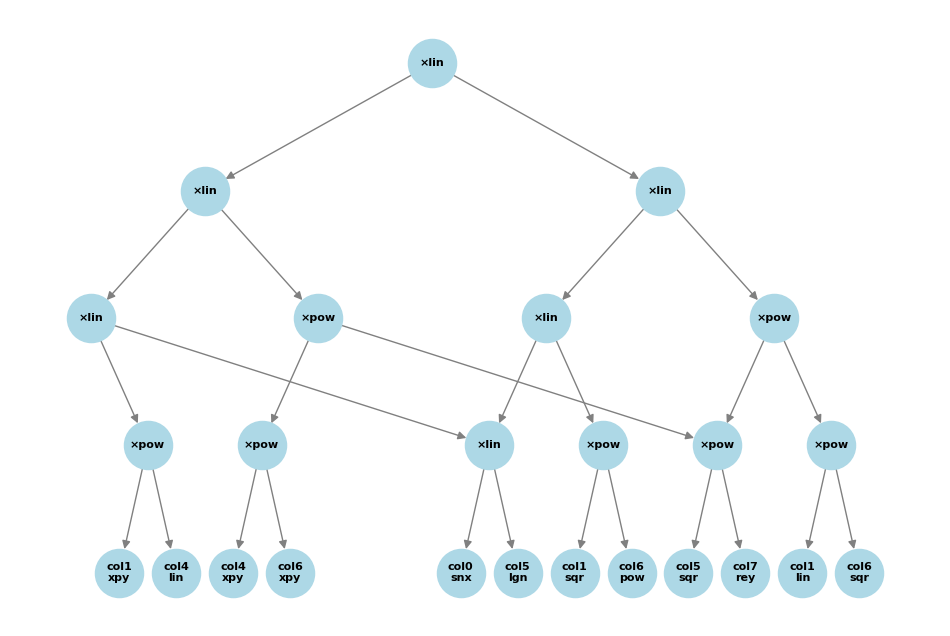

In [44]:
mssp.plot_graph(top_k=1)

<Axes: >

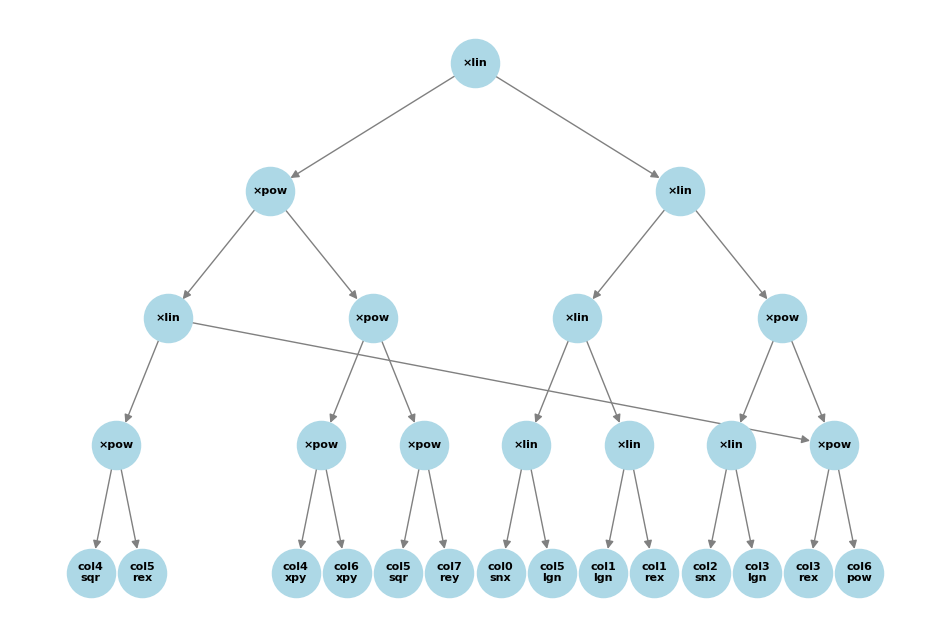

In [45]:
mssp.plot_graph(top_k=2)